In [2]:
import tomllib
from pathlib import Path
import pandas as pd

RUNS = 'runs'
PREFIX = 'graphene_borrar'          # <crystal.name>_<calculation.ID> (without the _NN of a sweep)

# sweep table written in {PREFIX}_sweep.txt by executeTB.py: one row per calculation, one column per swept key:

# las líneas que empiezan por #, son comentarios
# las columnas van separadas por tabuladores.
## sweep of tilt_config.xtoml (2026-09-26 16:51:20)
#index   name    Field.chi
#0       graphene_tilt_00        0.0
#1       graphene_tilt_01        0.01805513019304479
#2       graphene_tilt_02        0.03611026038608958
#3       graphene_tilt_03        0.05416539057913437
#4       graphene_tilt_04        0.07222052077217916

# A single calculation (no sweep) has no table: it is treated as a sweep of one row and no swept keys.
sweep_path = Path(RUNS) / f'{PREFIX}_sweep.txt'
if sweep_path.exists():  # el cálculo se hizo sobre un conjunto sweep
    sweep = pd.read_csv(sweep_path, sep='\t', comment='#')
else: # solo un cálculo (no hay barrido, no table sweep.txt)
    sweep = pd.DataFrame({'index': [0], 'name': [PREFIX]})
# the pd dataframes have the follwoing structure if there is a sweep
#    index              name  Field.chi
# 0      0  graphene_tilt_00   0.000000
# 1      1  graphene_tilt_01   0.018055
#
# or, if there is no sweep
#    index           name
# 0      0  graphene_tilt

swept_keys = [k for k in sweep.columns if k not in ('index', 'name')] # Nommbres de las columnas

# full input of every calculation, from its runs/<name>.toml (same order as the rows of sweep)
#   e.g. configs[i]['Field']['lambda']
configs = []
for name in sweep['name']:
    with open(Path(RUNS) / f'{name}.toml', 'rb') as f:
        configs.append(tomllib.load(f))

print(sweep)

   index                name  Field.chi
0      0  graphene_borrar_00   0.000000
1      1  graphene_borrar_01   0.261799


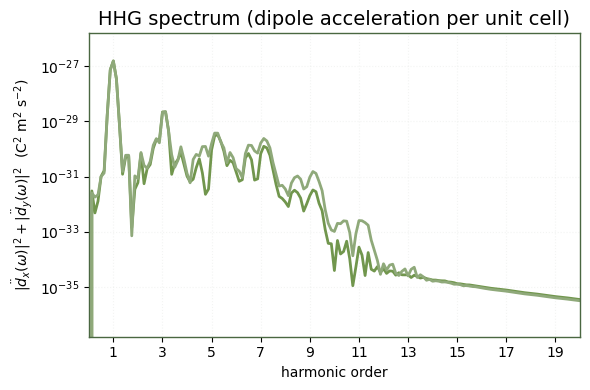

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('/home/lplaja/.matplotlib/stylelib/obsidian.mplstyle')

def gather_data(fnamelist):
    """Read the dipole velocity of several calculations and compute its time derivative.

    fnamelist: list of runs/<name>_dipole_velocity.txt files (columns t, vd_x, vd_y; '#' lines skipped).
    All files must share the time grid of the first one.
    Returns
        t                          (n_t,)            time, s
        dipole_vel_x, dipole_vel_y (n_t, n_calc)     dipole velocity per unit cell, C m/s
        accel_x, accel_y           (n_t, n_calc)   dipole acceleration d(vd)/dt, C m/s^2,
                                                     without the first 2 and last 3 samples
    One column per file, in the order of fnamelist.
    """

    n_columns=len(fnamelist)
    # first take t from the first file. That means that t is always the same for all the calculations and
    # cannot be the result of a sweep
    t=[]
    filename=fnamelist[0]
    with open(filename, "r") as fh:  
        for line in fh:
            if line.startswith("#"):
                continue
            it, ix, iy = map(complex, line.split())
            t.append(np.real(it))

    t=np.array(t)

    data = [np.loadtxt(f) for f in fnamelist]           # one array (nt, 3) per file: t, vdx, vdy
    t = data[0][:, 0]
    dipole_vel_x = np.column_stack([d[:, 1] for d in data])   # (nt, n_calc), column i = calculation i
    dipole_vel_y = np.column_stack([d[:, 2] for d in data])

    return t, dipole_vel_x, dipole_vel_y

fnamelist=[f"{RUNS}/{name}_dipole_velocity.txt" for name in sweep['name']]

labels=sweep['Field.chi']

t, dipole_vel_x, dipole_vel_y =gather_data(fnamelist)

nt=t.size
dt=t[1]-t[0]
FT_npts = nt//2

imask=int(nt/10)
mask=np.ones(nt)
igauss=np.arange(0,imask)
mask[nt-imask:]*=np.exp(-(igauss/10)**2)

vd_x = dipole_vel_x*mask[:, None]                       # window on vd (not on the acceleration)
vd_y = dipole_vel_y*mask[:, None]
omega = 2*np.pi*np.fft.fftfreq(len(t), dt)[:, None]     # s^{-1}, one value per FFT bin
# FT of the velocity, C m. FT acceleration has units C m/s, luego es una densidad espectral de aceleración a(w)/Delta w
# numpy's FFT uses exp(-i w t); conj -> amplitudes in the exp(-i w t) time convention of Field.py / slides
FT_accel_x = np.conj(1j*omega*np.fft.fft(vd_x, axis=0)*dt)[:FT_npts]
FT_accel_y = np.conj(1j*omega*np.fft.fft(vd_y, axis=0)*dt)[:FT_npts]

fig, ax=plt.subplots(1,1, figsize=(6,4))

# harmonic order: FFT index / duration of the record in optical periods (was a hardcoded 8)
T0 = configs[0]['Field']['lambda']*1e-9/299792458                     # driver period, s
assert len({c['Field']['lambda'] for c in configs}) == 1, "all calculations must have the same wavelength"
w = omega[:FT_npts, 0]*T0/(2*np.pi)  
spectrum=np.abs(FT_accel_x)**2+np.abs(FT_accel_y)**2          # C^2 m^2 / s^2
#ax.semilogy(w, spectrum, label=labels)
ax.semilogy(w, spectrum)
ax.set_xlabel("harmonic order")
ax.set_ylabel(r"$|\ddot d_x(\omega)|^2+|\ddot d_y(\omega)|^2$  (C$^2$ m$^2$ s$^{-2}$)")
ax.set_title("HHG spectrum (dipole acceleration per unit cell)")
#ax.legend()
ax.set_xlim(0,20)
ax.set_ylim(spectrum.max()*1e-10, spectrum.max()*10)   
ax.set_xticks(np.arange(1, 20, 2))        # 10 decades below the maximum
ax.grid(True, linestyle='dotted')

plt.tight_layout()

In [4]:
import tomllib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- harmonic analysis: Stokes parameters and polarization ellipse of every harmonic order
import sys
# find the repository's src/ folder (first parent directory that contains src/Field.py) and import Field from it
repo_src = next(p/'src' for p in Path.cwd().resolve().parents if (p/'src'/'Field.py').exists())
sys.path.insert(0, str(repo_src))
import Field                  # Field.ellipse_to_jones uses the same (phi, delta_varphi) convention as PulsedField

HARM_WIDTH = 1.0              # width of the integration window around each harmonic q, in harmonic orders (1 or 2)
Q_VALUES = np.arange(1, 20, 2)  # harmonic orders to analyse (odd orders only)

def harmonic_table(FTx, FTy, w, q_values, width, sweep, swept_keys):
    """Return a DataFrame with one row per (calculation, harmonic q): integrated intensity and averaged polarization.

    Inputs
        FTx, FTy    FT of the dipole acceleration, shape (n_w, n_calc), column i = calculation i of the sweep.
                    They are already in the exp(-i omega t) convention of Field.py and of the slides
                    (conjugated after numpy's FFT), so a_par = FTx, a_perp = FTy  (par = x, perp = y).
        w           harmonic order of each row of FTx, FTy
        q_values    harmonic orders to analyse
        width       window [q - width/2, q + width/2) around each q, in harmonic orders
        sweep       table of calculations (one row per calculation, same order as the columns of FTx, FTy)
        swept_keys  names of the swept parameters, copied into every row of the result

    Stokes parameters at each frequency (slide 48):
        S0 = |a_par|^2 + |a_perp|^2        S1 = |a_par|^2 - |a_perp|^2
        S2 = 2 Re(a_par a_perp^*)          S3 = 2 Im(a_par a_perp^*) = i (a_perp a_par^* - a_perp^* a_par)

    Quantities computed in the window of each q:
        I   = sum(S0) dq                 intensity: integral of |FT|^2 over harmonic order (C^2 m^2 s^-2)
        S_i = sum(S_i) / sum(S0)         normalized Stokes parameters (S0 = 1), i.e. average weighted with |FT|^2
        P   = |(S1, S2, S3)|             degree of polarization (< 1 if the polarization varies inside the window)
    Polarization ellipse of the polarized part:
        chi = atan2(S2, S1)/2            tilt angle, measured from e_par = x
        eps = tan(arcsin(S3/P)/2)        ellipticity, signed by the helicity
        (phi, delta_varphi) = Field.ellipse_to_jones(chi, eps)
    """
    if max(q_values) + width/2 > w[-1]:
        raise ValueError(f"harmonic {max(q_values)} is beyond the spectrum (max order {w[-1]:.1f})")

    # Stokes parameters for every frequency and every calculation, shape (n_w, n_calc)
    a_par, a_perp = FTx, FTy
    S0 = np.abs(a_par)**2 + np.abs(a_perp)**2
    S1 = np.abs(a_par)**2 - np.abs(a_perp)**2
    S2 = 2*np.real(a_par*np.conj(a_perp))
    S3 = 2*np.imag(a_par*np.conj(a_perp))
    dq = w[1] - w[0]           # spacing of the harmonic-order axis

    rows = []
    # i is the position of the calculation (column of S0...), not the row label of sweep:
    # enumerate keeps this correct even if sweep has been filtered and its labels are not 0, 1, 2...
    for i, (_, r) in enumerate(sweep.iterrows()):
        for q in q_values:
            win = (w >= q - width/2) & (w < q + width/2)   # half-open window: no bin is counted twice
            S0_sum = S0[win, i].sum()
            I = S0_sum*dq
            s1, s2, s3 = (S[win, i].sum()/S0_sum for S in (S1, S2, S3))
            P = np.sqrt(s1**2 + s2**2 + s3**2)
            chi = 0.5*np.arctan2(s2, s1)
            eps = np.tan(0.5*np.arcsin(np.clip(s3/P, -1, 1)))   # clip guards against rounding slightly above 1
            phi, delta_varphi = Field.ellipse_to_jones(chi, eps)
            rows.append({'name': r['name'], **{k: r[k] for k in swept_keys}, 'q': q, 'I': I,
                         'S1': s1, 'S2': s2, 'S3': s3, 'P': P, 'chi': chi, 'eps': eps,
                         'phi': phi, 'delta_varphi': delta_varphi})
    return pd.DataFrame(rows)

harm = harmonic_table(FT_accel_x, FT_accel_y, w, Q_VALUES, HARM_WIDTH, sweep, swept_keys)
harm

,name,Field.chi,q,I,S1,S2,S3,P,chi,eps,phi,delta_varphi
0,graphene_borrar_00,0.000000,1,3.336965e-28,1.000000,-1.920664e-16,2.488151e-17,1.000000,-9.603320e-17,1.244076e-17,0.000000,1.570796
1,graphene_borrar_00,0.000000,3,6.796692e-30,1.000000,-5.855776e-15,8.391445e-15,1.000000,-2.927888e-15,4.195723e-15,-0.000000,-0.968182
2,graphene_borrar_00,0.000000,5,1.209779e-30,1.000000,2.667287e-14,-2.572210e-15,1.000000,1.333643e-14,-1.286105e-15,0.000000,-0.096237
3,graphene_borrar_00,0.000000,7,6.042341e-31,1.000000,-3.148095e-14,3.732029e-14,1.000000,-1.574048e-14,1.866015e-14,-0.000000,-0.869295
4,graphene_borrar_00,0.000000,9,1.875718e-32,1.000000,4.964461e-13,3.917552e-13,1.000000,2.482231e-13,1.958776e-13,0.000000,0.668026
5,graphene_borrar_00,0.000000,11,1.542216e-34,1.000000,2.354076e-12,-5.933010e-12,1.000000,1.177038e-12,-2.966505e-12,0.000000,-1.193066
6,graphene_borrar_00,0.000000,13,2.659155e-35,1.000000,2.048237e-11,-2.356658e-11,1.000000,1.024118e-11,-1.178329e-11,0.000000,-0.855304
7,graphene_borrar_00,0.000000,15,1.172864e-35,1.000000,3.781329e-11,-4.223777e-11,1.000000,1.890664e-11,-2.111889e-11,0.000000,-0.840612
8,graphene_borrar_00,0.000000,17,7.722953e-36,1.000000,2.287552e-11,6.845193e-12,1.000000,1.143776e-11,3.422597e-12,0.000000,0.290757
9,graphene_borrar_00,0.000000,19,4.528230e-36,1.000000,3.724884e-11,2.910548e-11,1.000000,1.862442e-11,1.455274e-11,0.000000,0.663283


In [5]:
import tomllib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- harmonic analysis: Stokes parameters and polarization ellipse of every harmonic order
import sys
# find the repository's src/ folder (first parent directory that contains src/Field.py) and import Field from it
repo_src = next(p/'src' for p in Path.cwd().resolve().parents if (p/'src'/'Field.py').exists())
sys.path.insert(0, str(repo_src))
import Field                  # Field.ellipse_to_jones uses the same (phi, delta_varphi) convention as PulsedField

HARM_WIDTH = 1.0              # width of the integration window around each harmonic q, in harmonic orders (1 or 2)
Q_VALUES = np.arange(1, 20, 2)  # harmonic orders to analyse (odd orders only)

def harmonic_table(FTx, FTy, w, q_values, width, sweep, swept_keys):
    """Return a DataFrame with one row per (calculation, harmonic q): integrated intensity and averaged polarization.

    Inputs
        FTx, FTy    FT of the dipole acceleration, shape (n_w, n_calc), column i = calculation i of the sweep.
                    They are already in the exp(-i omega t) convention of Field.py and of the slides
                    (conjugated after numpy's FFT), so a_par = FTx, a_perp = FTy  (par = x, perp = y).
        w           harmonic order of each row of FTx, FTy
        q_values    harmonic orders to analyse
        width       window [q - width/2, q + width/2) around each q, in harmonic orders
        sweep       table of calculations (one row per calculation, same order as the columns of FTx, FTy)
        swept_keys  names of the swept parameters, copied into every row of the result

    Stokes parameters at each frequency (slide 48):
        S0 = |a_par|^2 + |a_perp|^2        S1 = |a_par|^2 - |a_perp|^2
        S2 = 2 Re(a_par a_perp^*)          S3 = 2 Im(a_par a_perp^*) = i (a_perp a_par^* - a_perp^* a_par)

    Quantities computed in the window of each q:
        I   = sum(S0) dq                 intensity: integral of |FT|^2 over harmonic order (C^2 m^2 s^-2)
        S_i = sum(S_i) / sum(S0)         normalized Stokes parameters (S0 = 1), i.e. average weighted with |FT|^2
        P   = |(S1, S2, S3)|             degree of polarization (< 1 if the polarization varies inside the window)
    Polarization ellipse of the polarized part:
        chi = atan2(S2, S1)/2            tilt angle, measured from e_par = x
        eps = tan(arcsin(S3/P)/2)        ellipticity, signed by the helicity
        (phi, delta_varphi) = Field.ellipse_to_jones(chi, eps)
    """
    if max(q_values) + width/2 > w[-1]:
        raise ValueError(f"harmonic {max(q_values)} is beyond the spectrum (max order {w[-1]:.1f})")

    # Stokes parameters for every frequency and every calculation, shape (n_w, n_calc)
    a_par, a_perp = FTx, FTy
    S0 = np.abs(a_par)**2 + np.abs(a_perp)**2
    S1 = np.abs(a_par)**2 - np.abs(a_perp)**2
    S2 = 2*np.real(a_par*np.conj(a_perp))
    S3 = 2*np.imag(a_par*np.conj(a_perp))
    dq = w[1] - w[0]           # spacing of the harmonic-order axis

    rows = []
    # i is the position of the calculation (column of S0...), not the row label of sweep:
    # enumerate keeps this correct even if sweep has been filtered and its labels are not 0, 1, 2...
    for i, (_, r) in enumerate(sweep.iterrows()):
        for q in q_values:
            win = (w >= q - width/2) & (w < q + width/2)   # half-open window: no bin is counted twice
            S0_sum = S0[win, i].sum()
            I = S0_sum*dq
            s1, s2, s3 = (S[win, i].sum()/S0_sum for S in (S1, S2, S3))
            P = np.sqrt(s1**2 + s2**2 + s3**2)
            chi = 0.5*np.arctan2(s2, s1)
            eps = np.tan(0.5*np.arcsin(np.clip(s3/P, -1, 1)))   # clip guards against rounding slightly above 1
            phi, delta_varphi = Field.ellipse_to_jones(chi, eps)
            rows.append({'name': r['name'], **{k: r[k] for k in swept_keys}, 'q': q, 'I': I,
                         'S1': s1, 'S2': s2, 'S3': s3, 'P': P, 'chi': chi, 'eps': eps,
                         'phi': phi, 'delta_varphi': delta_varphi})
    return pd.DataFrame(rows)

harm = harmonic_table(FT_accel_x, FT_accel_y, w, Q_VALUES, HARM_WIDTH, sweep, swept_keys)
harm

,name,Field.chi,q,I,S1,S2,S3,P,chi,eps,phi,delta_varphi
0,graphene_borrar_00,0.000000,1,3.336965e-28,1.000000,-1.920664e-16,2.488151e-17,1.000000,-9.603320e-17,1.244076e-17,0.000000,1.570796
1,graphene_borrar_00,0.000000,3,6.796692e-30,1.000000,-5.855776e-15,8.391445e-15,1.000000,-2.927888e-15,4.195723e-15,-0.000000,-0.968182
2,graphene_borrar_00,0.000000,5,1.209779e-30,1.000000,2.667287e-14,-2.572210e-15,1.000000,1.333643e-14,-1.286105e-15,0.000000,-0.096237
3,graphene_borrar_00,0.000000,7,6.042341e-31,1.000000,-3.148095e-14,3.732029e-14,1.000000,-1.574048e-14,1.866015e-14,-0.000000,-0.869295
4,graphene_borrar_00,0.000000,9,1.875718e-32,1.000000,4.964461e-13,3.917552e-13,1.000000,2.482231e-13,1.958776e-13,0.000000,0.668026
5,graphene_borrar_00,0.000000,11,1.542216e-34,1.000000,2.354076e-12,-5.933010e-12,1.000000,1.177038e-12,-2.966505e-12,0.000000,-1.193066
6,graphene_borrar_00,0.000000,13,2.659155e-35,1.000000,2.048237e-11,-2.356658e-11,1.000000,1.024118e-11,-1.178329e-11,0.000000,-0.855304
7,graphene_borrar_00,0.000000,15,1.172864e-35,1.000000,3.781329e-11,-4.223777e-11,1.000000,1.890664e-11,-2.111889e-11,0.000000,-0.840612
8,graphene_borrar_00,0.000000,17,7.722953e-36,1.000000,2.287552e-11,6.845193e-12,1.000000,1.143776e-11,3.422597e-12,0.000000,0.290757
9,graphene_borrar_00,0.000000,19,4.528230e-36,1.000000,3.724884e-11,2.910548e-11,1.000000,1.862442e-11,1.455274e-11,0.000000,0.663283


/tmp/ipykernel_3597808/301375801.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 0].legend(fontsize=7)


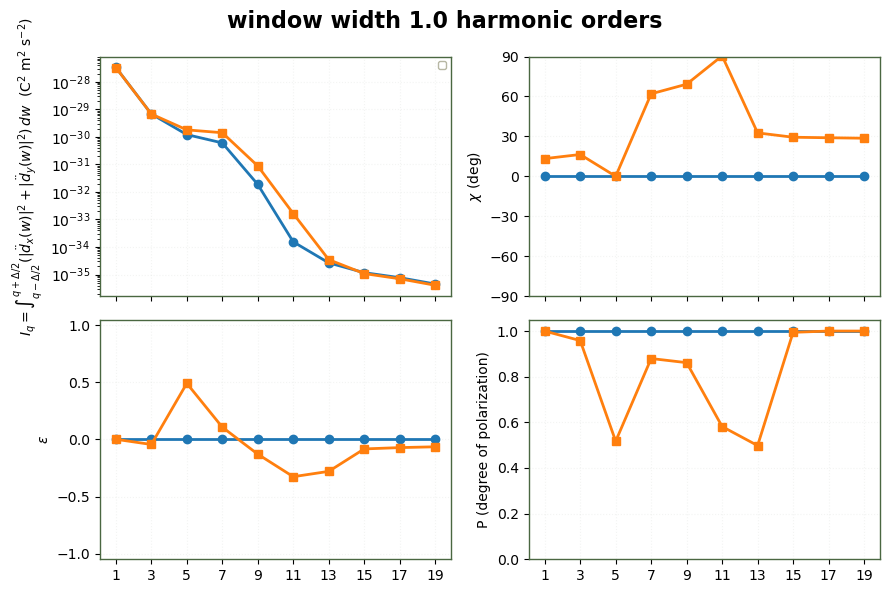

In [6]:
# ---- per-harmonic plots: one line per calculation of the sweep

COLORS = plt.get_cmap('tab10').colors          # 10 distinct categorical colors
MARKERS = 'osD^v<>pXh'


I_REL_MIN = 1e-8   # polarization is hidden where I_q < I_REL_MIN * max_q I_q of that calculation
                   # (no harmonic signal there: chi, eps and P would be numerical noise)

fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
# groupby('name'): one sub-table g per calculation (all its harmonics q);
# sort=False keeps the order of the sweep, so each g matches its entry in labels
for k, (name, g) in enumerate(harm.groupby('name', sort=False)):
#for (name, g), lab in zip(harm.groupby('name', sort=False), labels):
    style = dict(color=COLORS[k % len(COLORS)], marker=MARKERS[k % len(MARKERS)], linestyle='-')

    axs[0, 0].semilogy(g['q'], g['I'], **style)
    ok = g['I'] > I_REL_MIN*g['I'].max()          # harmonics with enough signal
    # where(ok): NaN where ok is False -> the line is broken there instead of joining distant harmonics
    
    chi_unwrapped=np.unwrap(g['chi'], period=np.pi)    
    axs[0, 1].plot(g['q'][ok], np.rad2deg(chi_unwrapped[ok]), **style)
    axs[1, 0].plot(g['q'], g['eps'].where(ok), **style)
    axs[1, 1].plot(g['q'], g['P'].where(ok), **style)

axs[0, 0].set_ylabel(r"$I_q=\int_{q-\Delta/2}^{q+\Delta/2} (|\ddot d_x(w)|^2+|\ddot d_y(w)|^2)\,dw$  (C$^2$ m$^2$ s$^{-2}$)")
axs[0, 1].set_ylabel(r"$\chi$ (deg)");  axs[0, 1].set_ylim(-90, 90);  axs[0, 1].set_yticks(np.arange(-90, 91, 30))
axs[1, 0].set_ylabel(r"$\varepsilon$");  axs[1, 0].set_ylim(-1.05, 1.05)
axs[1, 1].set_ylabel("P (degree of polarization)");  axs[1, 1].set_ylim(0, 1.05)
for ax in axs.flat:
    ax.set_xticks(Q_VALUES);  ax.grid(True, linestyle='dotted')
#for ax in axs[1]:
#    ax.set_xlabel("harmonic order q")
axs[0, 0].legend(fontsize=7)
fig.suptitle(f"window width {HARM_WIDTH} harmonic orders")
plt.tight_layout()

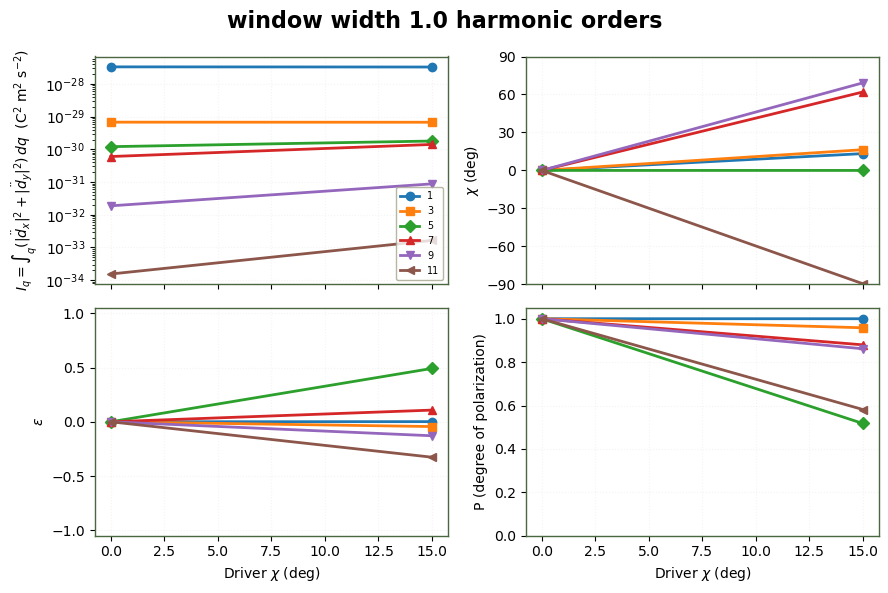

In [7]:
# ---- per-harmonic plots: one line per harmonic

COLORS = plt.get_cmap('tab10').colors          # 10 distinct categorical colors
MARKERS = 'osD^v<>pXh'



I_REL_MIN = 1e-8   # polarization is hidden where I_q < I_REL_MIN * max_q I_q of that calculation
                   # (no harmonic signal there: chi, eps and P would be numerical noise)

fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
# groupby('name'): one sub-table g per calculation (all its harmonics q);
# sort=False keeps the order of the sweep, so each g matches its entry in labels
for k, (q, g) in enumerate(harm.groupby('q')):  # k = 0, 1, 2, ... : position of the harmonic
    if q>11: continue
    style = dict(color=COLORS[k % len(COLORS)], marker=MARKERS[k % len(MARKERS)], linestyle='-')

    axs[0, 0].semilogy(g['Field.chi']/np.pi*180, g['I'], label=q, **style)
    ok = g['I'] > I_REL_MIN*g['I'].max()          # harmonics with enough signal
    # where(ok): NaN where ok is False -> the line is broken there instead of joining distant harmonics
    
    chi_unwrapped=np.unwrap(g['chi'], period=np.pi)

    #axs[0, 1].plot(g['Field.chi']/np.pi*180, np.rad2deg(g['chi'].where(ok)),  **style)
    axs[0, 1].plot(g['Field.chi']/np.pi*180, np.rad2deg(chi_unwrapped[ok]),  **style)
    axs[1, 0].plot(g['Field.chi']/np.pi*180, g['eps'].where(ok), **style)
    axs[1, 1].plot(g['Field.chi']/np.pi*180, g['P'].where(ok), **style)

axs[0, 0].set_ylabel(r"$I_q=\int_q (|\ddot d_x|^2+|\ddot d_y|^2)\,dq$  (C$^2$ m$^2$ s$^{-2}$)")
axs[0, 1].set_ylabel(r"$\chi$ (deg)");  axs[0, 1].set_ylim(-90, 90);  axs[0, 1].set_yticks(np.arange(-90, 91, 30))
axs[1, 0].set_ylabel(r"$\varepsilon$");  axs[1, 0].set_ylim(-1.05, 1.05)
axs[1, 1].set_ylabel("P (degree of polarization)");  axs[1, 1].set_ylim(0, 1.05)
#for ax in axs.flat:
#    ax.set_xticks(Q_VALUES);  ax.grid(True, linestyle='dotted')
for ax in axs[1]:
    ax.set_xlabel(r"Driver $\chi$ (deg)")
axs[0, 0].legend(fontsize=7)
fig.suptitle(f"window width {HARM_WIDTH} harmonic orders")
plt.tight_layout()